In [1]:
import pandas as pd
import numpy as np
All_Data = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/5. Final consolidation of all data/5.A. Data created in 5./5.2./Final affiliations.xlsx')
All_Data = All_Data.iloc[: , 1:] 
print(All_Data.shape)
print(All_Data.head())

(22790, 39)
  Journal_Name  Authors_count            Authors  Article_ID content_type  \
0          RES            1.0    S. S. Alexander     2967475      Article   
1          RES            1.0       J. C. R. Dow     2967408      Article   
2          RES            1.0       J. C. R. Dow     2967408      Article   
3          RES            1.0  M. Bronfenbrenner     2967405      Article   
4          RES            1.0       J. C. R. Dow     2967406      Article   

                             stable_url  Year Ref_type  \
0  https://www.jstor.org/stable/2967475  1940    found   
1  https://www.jstor.org/stable/2967408  1940    found   
2  https://www.jstor.org/stable/2967408  1940    found   
3  https://www.jstor.org/stable/2967405  1940    found   
4  https://www.jstor.org/stable/2967406  1940    found   

                                          ref_string  \
0  MR. KEYNES AND MR. MARX 135\n\nabove-noted dif...   
1  202 THE REVIEW OF ECONOMIC STUDIES\n\neveryone...   
2  202 T

In [2]:
mask_journal = All_Data['Journal_Name'].isin(['JPE'])
Data = All_Data[mask_journal]
print(Data.shape)
Data = Data.replace(['National Bureau Of Economic Research', 'Centre For Economic Policy Research (Cepr, England)','Canadian Institute For Advanced Research (Cifar)','Centre For Operations Research And Econometrics (Core, France)','National Institute Of Economic And Social Research, London','None'],"")
Data = Data.reset_index(drop=True)
print(Data.shape)
print(Data.head())

(3823, 39)
(3823, 39)
  Journal_Name  Authors_count                              Authors  \
0          JPE            1.0                         Gerhard Colm   
1          JPE            1.0                        Jules Backman   
2          JPE            2.0  William Fellner And Howard S. Ellis   
3          JPE            1.0                        Harvey Pinney   
4          JPE            1.0                    George J. Stigler   

   Article_ID content_type                            stable_url  Year  \
0     1825913      Article  https://www.jstor.org/stable/1825913  1940   
1     1825487      Article  https://www.jstor.org/stable/1825487  1940   
2     1825486      Article  https://www.jstor.org/stable/1825486  1940   
3     1825485      Article  https://www.jstor.org/stable/1825485  1940   
4     1825484      Article  https://www.jstor.org/stable/1825484  1940   

  Ref_type                                         ref_string  \
0    found  COMMENTS ON W. I. KING: "ARE WE SUF

In [3]:
Data['0_auth_affs_count'] = ""
Data['1_auth_affs_count'] = ""
Data['2_auth_affs_count'] = ""
Data['3_auth_affs_count'] = ""
Data['4_auth_affs_count'] = ""
Data['5_auth_affs_count'] = ""
Data['6_auth_affs_count'] = ""

Data['0_auth_affs_0_weight'] = ""
Data['0_auth_affs_1_weight'] = ""
Data['0_auth_affs_2_weight'] = ""
Data['0_auth_affs_3_weight'] = ""
Data['0_auth_affs_4_weight'] = ""

Data['1_auth_affs_0_weight'] = ""
Data['1_auth_affs_1_weight'] = ""
Data['1_auth_affs_2_weight'] = ""
Data['1_auth_affs_3_weight'] = ""
Data['1_auth_affs_4_weight'] = ""

Data['2_auth_affs_0_weight'] = ""
Data['2_auth_affs_1_weight'] = ""
Data['2_auth_affs_2_weight'] = ""
Data['2_auth_affs_3_weight'] = ""
Data['2_auth_affs_4_weight'] = ""

Data['3_auth_affs_0_weight'] = ""
Data['3_auth_affs_1_weight'] = ""
Data['3_auth_affs_2_weight'] = ""
Data['3_auth_affs_3_weight'] = ""
Data['3_auth_affs_4_weight'] = ""

Data['4_auth_affs_0_weight'] = ""
Data['4_auth_affs_1_weight'] = ""
Data['4_auth_affs_2_weight'] = ""
Data['4_auth_affs_3_weight'] = ""

Data['5_auth_affs_0_weight'] = ""

Data['6_auth_affs_0_weight'] = ""

Data['7_auth_affs_0_weight'] = ""


#for i in range(3600,3823):
    
for i in range(len(Data)):
    # Check the number of authors
    if Data.iloc[i]['Authors_count'] == 1:
        # Apply the weighting to each author and their affiliations
        author_weight = 1
        
        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.isnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '0_auth_affs_count'] = 3
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '0_auth_affs_count'] = 4
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.notnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '0_auth_affs_count'] = 5
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_4_weight'] = author_weight/affiliations
        
    if Data.iloc[i]['Authors_count'] == 2:
        # Apply the weighting to each author and their affiliations
        author_weight = 1/2

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.isnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '0_auth_affs_count'] = 3
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '0_auth_affs_count'] = 4
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.notnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '0_auth_affs_count'] = 5
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_4_weight'] = author_weight/affiliations
        
        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.isnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '1_auth_affs_count'] = 3
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '1_auth_affs_count'] = 4
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.notnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '1_auth_affs_count'] = 5
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_4_weight'] = author_weight/affiliations

    if Data.iloc[i]['Authors_count'] == 3:
        # Apply the weighting to each author and their affiliations
        author_weight = 1/3

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.isnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '0_auth_affs_count'] = 3
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '0_auth_affs_count'] = 4
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.notnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '0_auth_affs_count'] = 5
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_4_weight'] = author_weight/affiliations
        
        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.isnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '1_auth_affs_count'] = 3
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '1_auth_affs_count'] = 4
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.notnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '1_auth_affs_count'] = 5
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.isnull().iloc[i]['2_Auth_affs_1'] and Data.isnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '2_auth_affs_count'] = affiliations
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.isnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '2_auth_affs_count'] = affiliations
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '2_auth_affs_count'] = 3
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.notnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 4')
            affiliations = 4
            Data.loc[i, '2_auth_affs_count'] = 4
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.notnull().iloc[i]['2_Auth_affs_3'] and Data.notnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 5')
            affiliations = 5
            Data.loc[i, '2_auth_affs_count'] = 5
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_4_weight'] = author_weight/affiliations


    if Data.iloc[i]['Authors_count'] == 4:
        # Apply the weighting to each author and their affiliations
        author_weight = 1/4

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.isnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '0_auth_affs_count'] = 3
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '0_auth_affs_count'] = 4
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.notnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '0_auth_affs_count'] = 5
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_4_weight'] = author_weight/affiliations
        
        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.isnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '1_auth_affs_count'] = 3
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '1_auth_affs_count'] = 4
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.notnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '1_auth_affs_count'] = 5
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.isnull().iloc[i]['2_Auth_affs_1'] and Data.isnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '2_auth_affs_count'] = affiliations
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.isnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '2_auth_affs_count'] = affiliations
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '2_auth_affs_count'] = 3
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.notnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 4')
            affiliations = 4
            Data.loc[i, '2_auth_affs_count'] = 4
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.notnull().iloc[i]['2_Auth_affs_3'] and Data.notnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 5')
            affiliations = 5
            Data.loc[i, '2_auth_affs_count'] = 5
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.isnull().iloc[i]['3_Auth_affs_1'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '3_auth_affs_count'] = affiliations
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.isnull().iloc[i]['3_Auth_affs_2'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '3_auth_affs_count'] = affiliations
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '3_auth_affs_count'] = 3
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.notnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 4')
            affiliations = 4
            Data.loc[i, '3_auth_affs_count'] = 4
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.notnull().iloc[i]['3_Auth_affs_3'] and Data.notnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 5')
            affiliations = 5
            Data.loc[i, '3_auth_affs_count'] = 5
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_4_weight'] = author_weight/affiliations


    if Data.iloc[i]['Authors_count'] == 5:
        # Apply the weighting to each author and their affiliations
        author_weight = 1/5

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.isnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '0_auth_affs_count'] = 3
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '0_auth_affs_count'] = 4
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.notnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '0_auth_affs_count'] = 5
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_4_weight'] = author_weight/affiliations
        
        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.isnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '1_auth_affs_count'] = 3
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '1_auth_affs_count'] = 4
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.notnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '1_auth_affs_count'] = 5
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.isnull().iloc[i]['2_Auth_affs_1'] and Data.isnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '2_auth_affs_count'] = affiliations
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.isnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '2_auth_affs_count'] = affiliations
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '2_auth_affs_count'] = 3
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.notnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 4')
            affiliations = 4
            Data.loc[i, '2_auth_affs_count'] = 4
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.notnull().iloc[i]['2_Auth_affs_3'] and Data.notnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 5')
            affiliations = 5
            Data.loc[i, '2_auth_affs_count'] = 5
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.isnull().iloc[i]['3_Auth_affs_1'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '3_auth_affs_count'] = affiliations
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.isnull().iloc[i]['3_Auth_affs_2'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 2
            Data.loc[i, '3_auth_affs_count'] = affiliations
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '3_auth_affs_count'] = 2
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.notnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 4')
            affiliations = 4
            Data.loc[i, '3_auth_affs_count'] = 4
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.notnull().iloc[i]['3_Auth_affs_3'] and Data.notnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 5')
            affiliations = 5
            Data.loc[i, '3_auth_affs_count'] = 5
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.isnull().iloc[i]['4_Auth_affs_1'] and Data.isnull().iloc[i]['4_Auth_affs_2'] and Data.isnull().iloc[i]['4_Auth_affs_3']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '4_auth_affs_count'] = affiliations
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.notnull().iloc[i]['4_Auth_affs_1'] and Data.isnull().iloc[i]['4_Auth_affs_2'] and Data.isnull().iloc[i]['4_Auth_affs_3']:
            print('4 aff 0')
            affiliations = 2
            Data.loc[i, '4_auth_affs_count'] = affiliations
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.notnull().iloc[i]['4_Auth_affs_1'] and Data.notnull().iloc[i]['4_Auth_affs_2'] and Data.isnull().iloc[i]['4_Auth_affs_3']:
            print('4 aff 0')
            affiliations = 3
            Data.loc[i, '4_auth_affs_count'] = 3
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.notnull().iloc[i]['4_Auth_affs_1'] and Data.notnull().iloc[i]['4_Auth_affs_2'] and Data.notnull().iloc[i]['4_Auth_affs_3']:
            print('4 aff 4')
            affiliations = 4
            Data.loc[i, '4_auth_affs_count'] = 4
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_3_weight'] = author_weight/affiliations


    if Data.iloc[i]['Authors_count'] == 6:
        # Apply the weighting to each author and their affiliations
        author_weight = 1/6

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.isnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '0_auth_affs_count'] = 3
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '0_auth_affs_count'] = 4
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.notnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '0_auth_affs_count'] = 5
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_4_weight'] = author_weight/affiliations
        
        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.isnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '1_auth_affs_count'] = 3
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '1_auth_affs_count'] = 4
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.notnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '1_auth_affs_count'] = 5
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.isnull().iloc[i]['2_Auth_affs_1'] and Data.isnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '2_auth_affs_count'] = affiliations
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.isnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '2_auth_affs_count'] = affiliations
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '2_auth_affs_count'] = 3
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.notnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 4')
            affiliations = 4
            Data.loc[i, '2_auth_affs_count'] = 4
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.notnull().iloc[i]['2_Auth_affs_3'] and Data.notnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 5')
            affiliations = 5
            Data.loc[i, '2_auth_affs_count'] = 5
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.isnull().iloc[i]['3_Auth_affs_1'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '3_auth_affs_count'] = affiliations
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.isnull().iloc[i]['3_Auth_affs_2'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '3_auth_affs_count'] = affiliations
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '3_auth_affs_count'] = 3
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.notnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 4')
            affiliations = 4
            Data.loc[i, '3_auth_affs_count'] = 4
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.notnull().iloc[i]['3_Auth_affs_3'] and Data.notnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 5')
            affiliations = 5
            Data.loc[i, '3_auth_affs_count'] = 5
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.isnull().iloc[i]['4_Auth_affs_1'] and Data.isnull().iloc[i]['4_Auth_affs_2'] and Data.isnull().iloc[i]['4_Auth_affs_3']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '4_auth_affs_count'] = affiliations
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.notnull().iloc[i]['4_Auth_affs_1'] and Data.isnull().iloc[i]['4_Auth_affs_2'] and Data.isnull().iloc[i]['4_Auth_affs_3']:
            print('4 aff 0')
            affiliations = 2
            Data.loc[i, '4_auth_affs_count'] = affiliations
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.notnull().iloc[i]['4_Auth_affs_1'] and Data.notnull().iloc[i]['4_Auth_affs_2'] and Data.isnull().iloc[i]['4_Auth_affs_3']:
            print('4 aff 0')
            affiliations = 3
            Data.loc[i, '4_auth_affs_count'] = 3
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.notnull().iloc[i]['4_Auth_affs_1'] and Data.notnull().iloc[i]['4_Auth_affs_2'] and Data.notnull().iloc[i]['4_Auth_affs_3']:
            print('4 aff 4')
            affiliations = 4
            Data.loc[i, '4_auth_affs_count'] = 4
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['5_Auth_affs_0']:
            print('3 aff 4')
            affiliations = 1
            Data.loc[i, '5_auth_affs_count'] = 1
            Data.loc[i, '5_auth_affs_0_weight'] = author_weight/affiliations

    if Data.iloc[i]['Authors_count'] == 7:
        # Apply the weighting to each author and their affiliations
        author_weight = 1/7

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.isnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '0_auth_affs_count'] = 3
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '0_auth_affs_count'] = 4
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.notnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '0_auth_affs_count'] = 5
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_4_weight'] = author_weight/affiliations
        
        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.isnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '1_auth_affs_count'] = 3
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '1_auth_affs_count'] = 4
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.notnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '1_auth_affs_count'] = 5
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.isnull().iloc[i]['2_Auth_affs_1'] and Data.isnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '2_auth_affs_count'] = affiliations
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.isnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '2_auth_affs_count'] = affiliations
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '2_auth_affs_count'] = 3
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.notnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 4')
            affiliations = 4
            Data.loc[i, '2_auth_affs_count'] = 4
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.notnull().iloc[i]['2_Auth_affs_3'] and Data.notnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 5')
            affiliations = 5
            Data.loc[i, '2_auth_affs_count'] = 5
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.isnull().iloc[i]['3_Auth_affs_1'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '3_auth_affs_count'] = affiliations
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.isnull().iloc[i]['3_Auth_affs_2'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '3_auth_affs_count'] = affiliations
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '3_auth_affs_count'] = 3
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.notnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 4')
            affiliations = 4
            Data.loc[i, '3_auth_affs_count'] = 4
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.notnull().iloc[i]['3_Auth_affs_3'] and Data.notnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 5')
            affiliations = 5
            Data.loc[i, '3_auth_affs_count'] = 5
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.isnull().iloc[i]['4_Auth_affs_1'] and Data.isnull().iloc[i]['4_Auth_affs_2'] and Data.isnull().iloc[i]['4_Auth_affs_3']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '4_auth_affs_count'] = affiliations
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.notnull().iloc[i]['4_Auth_affs_1'] and Data.isnull().iloc[i]['4_Auth_affs_2'] and Data.isnull().iloc[i]['4_Auth_affs_3']:
            print('4 aff 0')
            affiliations = 2
            Data.loc[i, '4_auth_affs_count'] = affiliations
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.notnull().iloc[i]['4_Auth_affs_1'] and Data.notnull().iloc[i]['4_Auth_affs_2'] and Data.isnull().iloc[i]['4_Auth_affs_3']:
            print('4 aff 0')
            affiliations = 3
            Data.loc[i, '4_auth_affs_count'] = 3
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.notnull().iloc[i]['4_Auth_affs_1'] and Data.notnull().iloc[i]['4_Auth_affs_2'] and Data.notnull().iloc[i]['4_Auth_affs_3']:
            print('4 aff 4')
            affiliations = 4
            Data.loc[i, '4_auth_affs_count'] = 4
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['5_Auth_affs_0']:
            print('3 aff 4')
            affiliations = 1
            Data.loc[i, '5_auth_affs_count'] = 1
            Data.loc[i, '5_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['6_Auth_affs_0']:
            print('3 aff 4')
            affiliations = 1
            Data.loc[i, '6_auth_affs_count'] = 1
            Data.loc[i, '6_auth_affs_0_weight'] = author_weight/affiliations

    if Data.iloc[i]['Authors_count'] == 8:
        # Apply the weighting to each author and their affiliations
        author_weight = 1/8

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.isnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.isnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '0_auth_affs_count'] = affiliations
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.isnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '0_auth_affs_count'] = 3
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.isnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '0_auth_affs_count'] = 4
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['0_Auth_affs_0'] and Data.notnull().iloc[i]['0_Auth_affs_1'] and Data.notnull().iloc[i]['0_Auth_affs_2'] and Data.notnull().iloc[i]['0_Auth_affs_3'] and Data.notnull().iloc[i]['0_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '0_auth_affs_count'] = 5
            Data.loc[i, '0_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '0_auth_affs_4_weight'] = author_weight/affiliations
        
        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.isnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.isnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '1_auth_affs_count'] = affiliations
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.isnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '1_auth_affs_count'] = 3
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.isnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 4
            Data.loc[i, '1_auth_affs_count'] = 4
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['1_Auth_affs_0'] and Data.notnull().iloc[i]['1_Auth_affs_1'] and Data.notnull().iloc[i]['1_Auth_affs_2'] and Data.notnull().iloc[i]['1_Auth_affs_3'] and Data.notnull().iloc[i]['1_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 5
            Data.loc[i, '1_auth_affs_count'] = 5
            Data.loc[i, '1_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '1_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.isnull().iloc[i]['2_Auth_affs_1'] and Data.isnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '2_auth_affs_count'] = affiliations
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.isnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('2 aff 0')
            affiliations = 2
            Data.loc[i, '2_auth_affs_count'] = affiliations
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.isnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '2_auth_affs_count'] = 3
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.notnull().iloc[i]['2_Auth_affs_3'] and Data.isnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 4')
            affiliations = 4
            Data.loc[i, '2_auth_affs_count'] = 4
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['2_Auth_affs_0'] and Data.notnull().iloc[i]['2_Auth_affs_1'] and Data.notnull().iloc[i]['2_Auth_affs_2'] and Data.notnull().iloc[i]['2_Auth_affs_3'] and Data.notnull().iloc[i]['2_Auth_affs_4']:
            print('3 aff 5')
            affiliations = 5
            Data.loc[i, '2_auth_affs_count'] = 5
            Data.loc[i, '2_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '2_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.isnull().iloc[i]['3_Auth_affs_1'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '3_auth_affs_count'] = affiliations
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.isnull().iloc[i]['3_Auth_affs_2'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '3_auth_affs_count'] = affiliations
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.isnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 0')
            affiliations = 3
            Data.loc[i, '3_auth_affs_count'] = 3
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.notnull().iloc[i]['3_Auth_affs_3'] and Data.isnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 4')
            affiliations = 4
            Data.loc[i, '3_auth_affs_count'] = 4
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['3_Auth_affs_0'] and Data.notnull().iloc[i]['3_Auth_affs_1'] and Data.notnull().iloc[i]['3_Auth_affs_2'] and Data.notnull().iloc[i]['3_Auth_affs_3'] and Data.notnull().iloc[i]['3_Auth_affs_4']:
            print('3 aff 5')
            affiliations = 5
            Data.loc[i, '3_auth_affs_count'] = 5
            Data.loc[i, '3_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_3_weight'] = author_weight/affiliations
            Data.loc[i, '3_auth_affs_4_weight'] = author_weight/affiliations

        # Check the number of affiliations from each author
        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.isnull().iloc[i]['4_Auth_affs_1'] and Data.isnull().iloc[i]['4_Auth_affs_2'] and Data.isnull().iloc[i]['4_Auth_affs_3']:
            print('1 aff 0')
            affiliations = 1
            Data.loc[i, '4_auth_affs_count'] = affiliations
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.notnull().iloc[i]['4_Auth_affs_1'] and Data.isnull().iloc[i]['4_Auth_affs_2'] and Data.isnull().iloc[i]['4_Auth_affs_3']:
            print('4 aff 0')
            affiliations = 2
            Data.loc[i, '4_auth_affs_count'] = affiliations
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_1_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.notnull().iloc[i]['4_Auth_affs_1'] and Data.notnull().iloc[i]['4_Auth_affs_2'] and Data.isnull().iloc[i]['4_Auth_affs_3']:
            print('4 aff 0')
            affiliations = 3
            Data.loc[i, '4_auth_affs_count'] = 3
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_2_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['4_Auth_affs_0'] and Data.notnull().iloc[i]['4_Auth_affs_1'] and Data.notnull().iloc[i]['4_Auth_affs_2'] and Data.notnull().iloc[i]['4_Auth_affs_3']:
            print('4 aff 4')
            affiliations = 4
            Data.loc[i, '4_auth_affs_count'] = 4
            Data.loc[i, '4_auth_affs_0_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_1_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_2_weight'] = author_weight/affiliations
            Data.loc[i, '4_auth_affs_3_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['5_Auth_affs_0']:
            print('3 aff 4')
            affiliations = 1
            Data.loc[i, '5_auth_affs_count'] = 1
            Data.loc[i, '5_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['6_Auth_affs_0']:
            print('3 aff 4')
            affiliations = 1
            Data.loc[i, '6_auth_affs_count'] = 1
            Data.loc[i, '6_auth_affs_0_weight'] = author_weight/affiliations

        if Data.notnull().iloc[i]['7_Auth_affs_0']:
            print('3 aff 4')
            affiliations = 1
            Data.loc[i, '7_auth_affs_count'] = 1
            Data.loc[i, '7_auth_affs_0_weight'] = author_weight/affiliations

    print(i)

1 aff 0
0
1 aff 0
1
1 aff 0
1 aff 0
2
1 aff 0
3
1 aff 0
4
1 aff 0
5
1 aff 0
6
1 aff 0
7
1 aff 0
8
1 aff 0
9
1 aff 0
10
1 aff 0
11
1 aff 0
12
1 aff 0
13
1 aff 0
14
1 aff 0
1 aff 0
15
1 aff 0
16
1 aff 0
17
1 aff 0
18
1 aff 0
19
1 aff 0
20
1 aff 0
21
1 aff 0
22
1 aff 0
23
1 aff 0
24
1 aff 0
25
1 aff 0
26
1 aff 0
27
1 aff 0
28
1 aff 0
29
1 aff 0
30
1 aff 0
31
1 aff 0
32
1 aff 0
33
1 aff 0
34
1 aff 0
35
1 aff 0
36
1 aff 0
37
1 aff 0
38
1 aff 0
39
1 aff 0
40
1 aff 0
41
1 aff 0
42
1 aff 0
43
1 aff 0
44
1 aff 0
45
1 aff 0
46
1 aff 0
47
1 aff 0
48
1 aff 0
49
1 aff 0
50
1 aff 0
51
1 aff 0
52
1 aff 0
53
1 aff 0
54
1 aff 0
55
1 aff 0
56
1 aff 0
57
1 aff 0
58
1 aff 0
59
1 aff 0
60
1 aff 0
61
1 aff 0
62
1 aff 0
63
1 aff 0
64
1 aff 0
65
1 aff 0
66
1 aff 0
67
1 aff 0
68
1 aff 0
69
1 aff 0
70
1 aff 0
71
1 aff 0
72
1 aff 0
73
1 aff 0
74
1 aff 0
75
1 aff 0
1 aff 0
76
1 aff 0
77
1 aff 0
78
1 aff 0
79
1 aff 0
80
1 aff 0
81
1 aff 0
82
1 aff 0
83
1 aff 0
84
1 aff 0
85
1 aff 0
86
1 aff 0
1 aff 0
1 aff 0
87
1 

In [4]:
# Excel output to get an overview of the data
Data.head
#Data.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/Data_Weights_applied.xlsx') 

<bound method NDFrame.head of      Journal_Name  Authors_count  \
0             JPE            1.0   
1             JPE            1.0   
2             JPE            2.0   
3             JPE            1.0   
4             JPE            1.0   
...           ...            ...   
3818          JPE            2.0   
3819          JPE            3.0   
3820          JPE            3.0   
3821          JPE            2.0   
3822          JPE            4.0   

                                                Authors  Article_ID  \
0                                          Gerhard Colm     1825913   
1                                         Jules Backman     1825487   
2                   William Fellner And Howard S. Ellis     1825486   
3                                         Harvey Pinney     1825485   
4                                     George J. Stigler     1825484   
...                                                 ...         ...   
3818                John Asker And Alexa

In [5]:
Data_to_melt= Data.copy()
print(Data_to_melt.shape)

(3823, 73)


In [6]:
Data_to_melt["0_Auth_affs_0 + Weight"] = Data_to_melt["0_Auth_affs_0"].astype(str) + "+" + Data_to_melt["0_auth_affs_0_weight"].astype(str)
Data_to_melt["0_Auth_affs_1 + Weight"] = Data_to_melt["0_Auth_affs_1"].astype(str) + "+" + Data_to_melt["0_auth_affs_1_weight"].astype(str)
Data_to_melt["0_Auth_affs_2 + Weight"] = Data_to_melt["0_Auth_affs_2"].astype(str) + "+" + Data_to_melt["0_auth_affs_2_weight"].astype(str)
Data_to_melt["0_Auth_affs_3 + Weight"] = Data_to_melt["0_Auth_affs_3"].astype(str) + "+" + Data_to_melt["0_auth_affs_3_weight"].astype(str)
Data_to_melt["0_Auth_affs_4 + Weight"] = Data_to_melt["0_Auth_affs_4"].astype(str) + "+" + Data_to_melt["0_auth_affs_4_weight"].astype(str)

Data_to_melt["1_Auth_affs_0 + Weight"] = Data_to_melt["1_Auth_affs_0"].astype(str) + "+" + Data_to_melt["1_auth_affs_0_weight"].astype(str)
Data_to_melt["1_Auth_affs_1 + Weight"] = Data_to_melt["1_Auth_affs_1"].astype(str) + "+" + Data_to_melt["1_auth_affs_1_weight"].astype(str)
Data_to_melt["1_Auth_affs_2 + Weight"] = Data_to_melt["1_Auth_affs_2"].astype(str) + "+" + Data_to_melt["1_auth_affs_2_weight"].astype(str)
Data_to_melt["1_Auth_affs_3 + Weight"] = Data_to_melt["1_Auth_affs_3"].astype(str) + "+" + Data_to_melt["1_auth_affs_3_weight"].astype(str)
Data_to_melt["1_Auth_affs_4 + Weight"] = Data_to_melt["1_Auth_affs_4"].astype(str) + "+" + Data_to_melt["1_auth_affs_4_weight"].astype(str)

Data_to_melt["2_Auth_affs_0 + Weight"] = Data_to_melt["2_Auth_affs_0"].astype(str) + "+" + Data_to_melt["2_auth_affs_0_weight"].astype(str)
Data_to_melt["2_Auth_affs_1 + Weight"] = Data_to_melt["2_Auth_affs_1"].astype(str) + "+" + Data_to_melt["2_auth_affs_1_weight"].astype(str)
Data_to_melt["2_Auth_affs_2 + Weight"] = Data_to_melt["2_Auth_affs_2"].astype(str) + "+" + Data_to_melt["2_auth_affs_2_weight"].astype(str)
Data_to_melt["2_Auth_affs_3 + Weight"] = Data_to_melt["2_Auth_affs_3"].astype(str) + "+" + Data_to_melt["2_auth_affs_3_weight"].astype(str)
Data_to_melt["2_Auth_affs_4 + Weight"] = Data_to_melt["2_Auth_affs_4"].astype(str) + "+" + Data_to_melt["2_auth_affs_4_weight"].astype(str)

Data_to_melt["3_Auth_affs_0 + Weight"] = Data_to_melt["3_Auth_affs_0"].astype(str) + "+" + Data_to_melt["3_auth_affs_0_weight"].astype(str)
Data_to_melt["3_Auth_affs_1 + Weight"] = Data_to_melt["3_Auth_affs_1"].astype(str) + "+" + Data_to_melt["3_auth_affs_1_weight"].astype(str)
Data_to_melt["3_Auth_affs_2 + Weight"] = Data_to_melt["3_Auth_affs_2"].astype(str) + "+" + Data_to_melt["3_auth_affs_2_weight"].astype(str)
Data_to_melt["3_Auth_affs_3 + Weight"] = Data_to_melt["3_Auth_affs_3"].astype(str) + "+" + Data_to_melt["3_auth_affs_3_weight"].astype(str)
#Data_to_melt["3_Auth_affs_4 + Weight"] = Data_to_melt["3_Auth_affs_4"].astype(str) + "+" + Data_to_melt["3_auth_affs_4_weight"].astype(str)

Data_to_melt["4_Auth_affs_0 + Weight"] = Data_to_melt["4_Auth_affs_0"].astype(str) + "+" + Data_to_melt["4_auth_affs_0_weight"].astype(str)
Data_to_melt["4_Auth_affs_1 + Weight"] = Data_to_melt["4_Auth_affs_1"].astype(str) + "+" + Data_to_melt["4_auth_affs_1_weight"].astype(str)
Data_to_melt["4_Auth_affs_2 + Weight"] = Data_to_melt["4_Auth_affs_2"].astype(str) + "+" + Data_to_melt["4_auth_affs_2_weight"].astype(str)
Data_to_melt["4_Auth_affs_3 + Weight"] = Data_to_melt["4_Auth_affs_3"].astype(str) + "+" + Data_to_melt["4_auth_affs_3_weight"].astype(str)

Data_to_melt["5_Auth_affs_0 + Weight"] = Data_to_melt["5_Auth_affs_0"].astype(str) + "+" + Data_to_melt["5_auth_affs_0_weight"].astype(str)

Data_to_melt["6_Auth_affs_0 + Weight"] = Data_to_melt["6_Auth_affs_0"].astype(str) + "+" + Data_to_melt["6_auth_affs_0_weight"].astype(str)


print(Data_to_melt.shape)
Data_to_melt.replace("nan+", np.nan, inplace= True)
print(Data_to_melt.head())

(3823, 98)
  Journal_Name  Authors_count                              Authors  \
0          JPE            1.0                         Gerhard Colm   
1          JPE            1.0                        Jules Backman   
2          JPE            2.0  William Fellner And Howard S. Ellis   
3          JPE            1.0                        Harvey Pinney   
4          JPE            1.0                    George J. Stigler   

   Article_ID content_type                            stable_url  Year  \
0     1825913      Article  https://www.jstor.org/stable/1825913  1940   
1     1825487      Article  https://www.jstor.org/stable/1825487  1940   
2     1825486      Article  https://www.jstor.org/stable/1825486  1940   
3     1825485      Article  https://www.jstor.org/stable/1825485  1940   
4     1825484      Article  https://www.jstor.org/stable/1825484  1940   

  Ref_type                                         ref_string  \
0    found  COMMENTS ON W. I. KING: "ARE WE SUFFERING\nFRO

In [7]:
# Excel output to get an overview of the data
Data_to_melt.head
#Data_to_melt.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/Data_Weights_applied_auth.xlsx') 

<bound method NDFrame.head of      Journal_Name  Authors_count  \
0             JPE            1.0   
1             JPE            1.0   
2             JPE            2.0   
3             JPE            1.0   
4             JPE            1.0   
...           ...            ...   
3818          JPE            2.0   
3819          JPE            3.0   
3820          JPE            3.0   
3821          JPE            2.0   
3822          JPE            4.0   

                                                Authors  Article_ID  \
0                                          Gerhard Colm     1825913   
1                                         Jules Backman     1825487   
2                   William Fellner And Howard S. Ellis     1825486   
3                                         Harvey Pinney     1825485   
4                                     George J. Stigler     1825484   
...                                                 ...         ...   
3818                John Asker And Alexa

In [8]:
Data_to_melt.rename(columns = {'Year':'year'}, inplace = True)

melted = Data_to_melt.melt(id_vars= ['Article_ID','year'], value_vars=["0_Auth_affs_0 + Weight","0_Auth_affs_1 + Weight","0_Auth_affs_2 + Weight","0_Auth_affs_3 + Weight", "0_Auth_affs_4 + Weight",
                                                              "1_Auth_affs_0 + Weight","1_Auth_affs_1 + Weight","1_Auth_affs_2 + Weight","1_Auth_affs_3 + Weight", "1_Auth_affs_4 + Weight",
                                                              "2_Auth_affs_0 + Weight","2_Auth_affs_1 + Weight","2_Auth_affs_2 + Weight","2_Auth_affs_3 + Weight", "2_Auth_affs_4 + Weight",
                                                              "3_Auth_affs_0 + Weight","3_Auth_affs_1 + Weight","3_Auth_affs_2 + Weight","3_Auth_affs_3 + Weight",
                                                              "4_Auth_affs_0 + Weight","4_Auth_affs_1 + Weight","4_Auth_affs_2 + Weight","4_Auth_affs_3 + Weight",
                                                              "5_Auth_affs_0 + Weight","6_Auth_affs_0 + Weight"]).dropna()

melted.rename(columns = {'variable':'Aff Number + Weight'}, inplace = True)
melted.rename(columns = {'value':'Aff + Weight'}, inplace = True)

melted = melted.sort_values(by=['year'])

print(melted.head())
print(melted.shape)

    Article_ID  year     Aff Number + Weight                 Aff + Weight
0      1825913  1940  0_Auth_affs_0 + Weight     Washington Dc (City)+1.0
23     1825908  1940  0_Auth_affs_0 + Weight    University Of Chicago+1.0
24     1824384  1940  0_Auth_affs_0 + Weight      Columbia University+1.0
25     1824382  1940  0_Auth_affs_0 + Weight       Cornell University+1.0
26     1824381  1940  0_Auth_affs_0 + Weight  University Of Edinburgh+1.0
(6304, 4)


In [9]:
melted[['Affiliation','Weight']] = melted['Aff + Weight'].str.split("+",expand=True) 
melted.replace("", np.nan, inplace= True)
melted["Weight"]= melted["Weight"].astype(float)
print(melted.head())
print(melted.shape)

    Article_ID  year     Aff Number + Weight                 Aff + Weight  \
0      1825913  1940  0_Auth_affs_0 + Weight     Washington Dc (City)+1.0   
23     1825908  1940  0_Auth_affs_0 + Weight    University Of Chicago+1.0   
24     1824384  1940  0_Auth_affs_0 + Weight      Columbia University+1.0   
25     1824382  1940  0_Auth_affs_0 + Weight       Cornell University+1.0   
26     1824381  1940  0_Auth_affs_0 + Weight  University Of Edinburgh+1.0   

                Affiliation  Weight  
0      Washington Dc (City)     1.0  
23    University Of Chicago     1.0  
24      Columbia University     1.0  
25       Cornell University     1.0  
26  University Of Edinburgh     1.0  
(6304, 6)


In [10]:
# Excel output to get an overview of the data
melted.head
Data.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/JPE_Weights_applied.xlsx') 

In [11]:
melted.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/JPE_Melted_Weights_applied.xlsx') 

In [12]:
Melted_to_aggregate= melted.copy()
Melted_to_aggregate = Melted_to_aggregate[['Article_ID','year', 'Affiliation', 'Weight']]
print(Melted_to_aggregate.head())
print(Melted_to_aggregate.shape)
Melted_to_aggregate.dtypes

Melted_to_count= melted.copy()
Melted_to_sum= melted.copy()

    Article_ID  year              Affiliation  Weight
0      1825913  1940     Washington Dc (City)     1.0
23     1825908  1940    University Of Chicago     1.0
24     1824384  1940      Columbia University     1.0
25     1824382  1940       Cornell University     1.0
26     1824381  1940  University Of Edinburgh     1.0
(6304, 4)


In [13]:
Melted_to_sum['aff_cum_sum'] = Melted_to_sum.groupby(['Affiliation'])['Weight'].cumsum()

#Melted_to_sum = Melted_to_sum[['Article_ID' , 'Affiliation','year', 'aff_cum_sum', 'Weight']]

Melted_to_sum = Melted_to_sum[['Article_ID' , 'Weight','Affiliation','year', 'aff_cum_sum'] ]
# Checking the top 20 occurances of Universities over the 70 years
highest_vals_sum = Melted_to_sum.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_sum = highest_vals_sum.nlargest(20,'aff_cum_sum')
highest_vals_sum

Melted_to_sum.tail()
print(highest_vals_sum)


       Article_ID    Weight                                     Affiliation  \
3814       652462  1.000000                           University Of Chicago   
3819       653714  0.333333           Massachusetts Institute Of Technology   
3796       657996  0.500000                              Harvard University   
22910      657922  0.500000                             Stanford University   
3820       653138  0.333333                            Princeton University   
3822       652463  0.250000                             Columbia University   
22918      655844  0.250000                      University Of Pennsylvania   
3800       657949  0.333333                                 Yale University   
22913      658161  0.250000                         Northwestern University   
3821       653690  0.166667           University Of California, Los Angeles   
3761       605309  0.500000                          University Of Michigan   
41799      421172  0.333333                      Car

(71, 5)
     Article_ID    Weight            Affiliation  year  aff_cum_sum
13      1824211  1.000000  University Of Chicago  1940          3.0
49      1825328  1.000000  University Of Chicago  1941         10.0
90      1825229  0.500000  University Of Chicago  1942         12.0
132     1826593  0.333333  University Of Chicago  1943         13.0
161     1830978  1.000000  University Of Chicago  1944         17.0
       Article_ID    Weight            Affiliation  year  aff_cum_sum
3692       503756  0.500000  University Of Chicago  2006   325.597222
3720       516737  0.500000  University Of Chicago  2007   328.597222
3760       588200  0.166667  University Of Chicago  2008   332.097222
22894      597301  0.333333  University Of Chicago  2009   332.763889
3814       652462  1.000000  University Of Chicago  2010   334.263889
(63, 5)


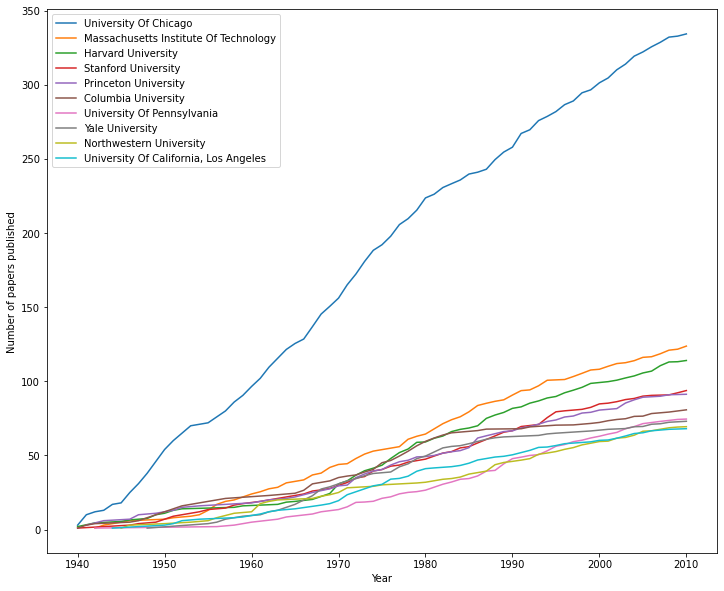

In [14]:
#Stacked plot on all years
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#print(melted.head())

a = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[0,2])].drop_duplicates(subset = ['year'], keep = 'last')
print(a.shape)
print(a.head())
print(a.tail())
b = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[1,2])].drop_duplicates(subset = ['year'], keep = 'last')
print(b.shape)
c = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[2,2])].drop_duplicates(subset = ['year'], keep = 'last')
d = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[3,2])].drop_duplicates(subset = ['year'], keep = 'last')
e = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[4,2])].drop_duplicates(subset = ['year'], keep = 'last')
f = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[5,2])].drop_duplicates(subset = ['year'], keep = 'last')
g = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[6,2])].drop_duplicates(subset = ['year'], keep = 'last')
h = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[7,2])].drop_duplicates(subset = ['year'], keep = 'last')
i = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[8,2])].drop_duplicates(subset = ['year'], keep = 'last')
j = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[9,2])].drop_duplicates(subset = ['year'], keep = 'last')
k = Melted_to_sum.loc[(Melted_to_sum['Affiliation'] == highest_vals_sum.iat[10,2])].drop_duplicates(subset = ['year'], keep = 'last')

plt.figure(figsize=(12,10))
plt.plot(a['year'],a['aff_cum_sum'], label = highest_vals_sum.iat[0,2])
plt.plot(b['year'],b['aff_cum_sum'], label = highest_vals_sum.iat[1,2])
plt.plot(c['year'],c['aff_cum_sum'], label = highest_vals_sum.iat[2,2])
plt.plot(d['year'],d['aff_cum_sum'], label = highest_vals_sum.iat[3,2])
plt.plot(e['year'],e['aff_cum_sum'], label = highest_vals_sum.iat[4,2])
plt.plot(f['year'],f['aff_cum_sum'], label = highest_vals_sum.iat[5,2])
plt.plot(g['year'],g['aff_cum_sum'], label = highest_vals_sum.iat[6,2])
plt.plot(h['year'],h['aff_cum_sum'], label = highest_vals_sum.iat[7,2])
plt.plot(i['year'],i['aff_cum_sum'], label = highest_vals_sum.iat[8,2])
plt.plot(j['year'],j['aff_cum_sum'], label = highest_vals_sum.iat[9,2])
#plt.plot(k['year'],k['aff_cum_counts'], label = highest_vals_10.iat[10,2])

#plt.title('Weighted number of papers published by year in Data from different Universities', fontsize=20)
plt.xlabel('Year')
plt.ylabel('Number of papers published')

plt.legend()
plt.show()